# RFC based on RDkit features  derived from SMILES predicting TDP1 ingibitors

## Content   <a name="content"></a>

1. [Upload the datasets](#1)
2. [Create the MORGAN2 RDkit features](#2)
3. [Data preperation for Machine learning](#3)
4. [Balancing](#4)
5. [Machine learning](#5)
6. [Scrutinizing for overfitting](#6)
7. [Five-fold cross-validation](#7)
8. [Hyperparameter tuning with Optuna](#8)
9. [Confusion matrix](#9)
10. [Matthews Correlation Coefficient (MCC)](#10)

In [1]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit import RDLogger
from rdkit.Chem import Descriptors
from rdkit.Chem import AllChem
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Disable RDKit warnings globally before defining the function
RDLogger.DisableLog('rdApp.*')

import rdkit
print(rdkit.__version__)

2023.09.5


## Upload the datasets <a name="1"></a>

In [2]:
# load the PubChem AID 686978 bioassy dataset
# https://pubchem.ncbi.nlm.nih.gov/bioassay/686978
# df = pd.read_csv('AID_686978_datatable.csv', sep=';', low_memory=False, on_bad_lines='skip')
df_smiles = pd.read_csv('AID_686978_data.csv', low_memory=False, on_bad_lines='skip')

# To avoid truncation of some columns during data frame display
pd.set_option('display.max_columns', None) 

# Display the data frame
print('Shape of the data frame: ', df_smiles.shape)
df_smiles.head()

Shape of the data frame:  (424003, 48)


,PUBCHEM_RESULT_TAG,PUBCHEM_SID,PUBCHEM_CID,PUBCHEM_EXT_DATASOURCE_SMILES,PUBCHEM_ACTIVITY_OUTCOME,PUBCHEM_ACTIVITY_SCORE,PUBCHEM_ACTIVITY_URL,PUBCHEM_ASSAYDATA_COMMENT,Phenotype,Potency,Efficacy,Analysis Comment,Activity_Score,Curve_Description,Fit_LogAC50,Fit_HillSlope,Fit_R2,Fit_InfiniteActivity,Fit_ZeroActivity,Fit_CurveClass,Excluded_Points,Max_Response,Activity at 0.0000295000 uM,Activity at 0.0000590000 uM,Activity at 0.0001503265 uM,Activity at 0.0002712146 uM,Activity at 0.0005895491 uM,Activity at 0.00117 uM,Activity at 0.00179 uM,Activity at 0.00299 uM,Activity at 0.00672 uM,Activity at 0.014 uM,Activity at 0.026 uM,Activity at 0.040 uM,Activity at 0.074 uM,Activity at 0.167 uM,Activity at 0.363 uM,Activity at 0.628 uM,Activity at 0.975 uM,Activity at 1.849 uM,Activity at 4.119 uM,Activity at 9.037 uM,Activity at 15.83 uM,Activity at 21.08 uM,Activity at 46.23 uM,Activity at 92.54 uM,Activity at 165.6 uM,Compound QC;;;;
0,1,109967258,50897788.0,CNCC1=NC2=C(C=C(C=C2)Cl)C(=N1)C3=CC=CN3,Active,42,http://assay.nih.gov/htsws/rest/display/dd-tdp...,NaN,Inhibitor,14.1254,136.5470,NaN,42.0,Partial curve; high efficacy,-4.850,1.0100,0.9948,-134.4880,2.0597,-2.1,0 0 0 0 0,-106.3110,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0597,NaN,NaN,NaN,NaN,0.5007,NaN,NaN,-17.4373,NaN,-48.5138,NaN,NaN,-106.3110,NaN,NaN,QC'd by AA Pharmaceuticals;;;
1,2,144206324,65628.0,CN1C2=C(C=C(C=C2)N(CCCl)CCCl)N=C1CCCC(=O)O,Active,41,http://assay.nih.gov/htsws/rest/display/dd-tdp...,NaN,Inhibitor,18.8375,82.1468,NaN,41.0,Partial curve; high efficacy,-4.725,1.9887,0.9829,-82.6097,-0.4629,-2.1,0 0 0 0 0 0 0 0,-70.9545,NaN,NaN,NaN,NaN,-3.2819,NaN,NaN,1.1641,NaN,5.8554,NaN,NaN,-1.8326,NaN,-4.9853,NaN,NaN,0.0798,NaN,-16.3921,NaN,NaN,-70.9545,NaN,NaN,QC'd by ACC;;;
2,3,144206325,14708.0,C[C@]12CC[C@H]3[C@H]([C@@H]1CC[C@]2(C)O)CC[C@@...,Inconclusive,10,http://assay.nih.gov/htsws/rest/display/dd-tdp...,NaN,Inhibitor,21.1360,39.2903,NaN,10.0,Single point of activity,-4.675,2.7868,0.9357,-43.4549,-4.1646,-3.0,0 0 0 0 0 0 0 0,-39.2270,NaN,NaN,NaN,NaN,-4.1400,NaN,NaN,-5.7369,NaN,0.1681,NaN,NaN,-8.2838,NaN,-6.9258,NaN,NaN,1.0188,NaN,-7.8647,NaN,NaN,-39.2270,NaN,NaN,QC'd by ACC;;;;
3,4,144206326,3085168.0,CC1=NC=C(C(=N1)N)CN(C=O)/C(=C(\CCO)/SS/C(=C(/C...,Inactive,0,http://assay.nih.gov/htsws/rest/display/dd-tdp...,NaN,Inactive,NaN,NaN,NaN,0.0,NaN,NaN,4.9549,0.6177,2.0768,-13.6113,4.0,0 0 0 0 0 0 0 1,-5.7844,NaN,NaN,NaN,NaN,-11.9232,NaN,NaN,-14.5799,NaN,8.2225,NaN,NaN,4.9756,NaN,4.8996,NaN,NaN,-10.1081,NaN,3.3805,NaN,NaN,-5.7844,NaN,NaN,QC'd by ACC;;;;
4,5,144206327,2449.0,CC1=C(C(=O)C(=C(C1=O)C)C(CCCCCC(=O)O)C2=CC=CC=...,Inconclusive,10,http://assay.nih.gov/htsws/rest/display/dd-tdp...,NaN,Inhibitor,26.6086,77.9682,NaN,10.0,Single point of activity,-4.575,3.5117,0.9609,-82.1111,-4.1429,-3.0,0 0 0 0 0 0 0 0,-72.3569,NaN,NaN,NaN,NaN,-10.6429,NaN,NaN,-2.5661,NaN,-11.5870,NaN,NaN,-4.3838,NaN,1.2149,NaN,NaN,1.7567,NaN,-5.8883,NaN,NaN,-72.3569,NaN,NaN,QC'd by ACC;;;;


In [3]:
# Keep only CID, SID and SMILES 
df_smiles = df_smiles [['PUBCHEM_SID', 'PUBCHEM_CID',	'PUBCHEM_EXT_DATASOURCE_SMILES']]

In [4]:
# Rename columns 
df_smiles.rename(columns={'PUBCHEM_CID':'CID',
                   'PUBCHEM_SID':'SID',
                   'PUBCHEM_EXT_DATASOURCE_SMILES' : 'SMILES'}, inplace=True)

# Display the data frame
print('Shape of the data frame: ', df_smiles.shape)
df_smiles.head()

Shape of the data frame:  (424003, 3)


,SID,CID,SMILES
0,109967258,50897788.0,CNCC1=NC2=C(C=C(C=C2)Cl)C(=N1)C3=CC=CN3
1,144206324,65628.0,CN1C2=C(C=C(C=C2)N(CCCl)CCCl)N=C1CCCC(=O)O
2,144206325,14708.0,C[C@]12CC[C@H]3[C@H]([C@@H]1CC[C@]2(C)O)CC[C@@...
3,144206326,3085168.0,CC1=NC=C(C(=N1)N)CN(C=O)/C(=C(\CCO)/SS/C(=C(/C...
4,144206327,2449.0,CC1=C(C(=O)C(=C(C1=O)C)C(CCCCCC(=O)O)C2=CC=CC=...


In [5]:
# loading the dataset for ML
df_targets = pd.read_csv('../TDP1_targetsInhibitors_CID_SID_IUPACs_functionalGroups/HF_TDP1_targetInhibitors_CID_SID_IUPAC_functionalGroups.csv', index_col=[0])

# Display the data frame
print('Shape of the data frame: ', df_targets.shape)
df_targets.head()

Shape of the data frame:  (101860, 5966)


CID       SID  target  \
0   1294294   4256765       1   
1    807804  47201366       0   
2    671673  24808112       0   
3  16017316  24395212       1   
4   2161711  49680337       0   

                                                UPAC  acenaphthylene  \
0  N-(5-benzoyl-2-morpholin-4-ylphenyl)furan-2-ca...               0   
1  N-(5-chloropyridin-2-yl)-2-(4-fluorophenyl)ace...               0   
2    2-(1-phenyltetrazol-5-yl)sulfanylacetohydrazide               0   
3  N-[2-[4-(2-fluorophenyl)piperazin-1-yl]-2-pyri...               0   
4  6-oxo-N-[2-(4-sulfamoylphenyl)ethyl]-1H-pyridi...               0   

   acenaphthyleno  acetaldehyde  acetamide  acetamido  acetamidoacetyl  \
0               0             0          0          0                0   
1               0             0          1          0                0   
2               0             0          0          0                0   
3               0             0          0          0                0   
4               0             0          0          0                0   

   acetamidoadamantane  acetamidoanilino  acetamidobenzenesulfonate  \
0                    0                 0                          0   
1                    0                 0                          0   
2                    0                 0                          0   
3                    0                 0                          0   
4                    0                 0                          0   

   acetamidobenzoate  acetamidobenzoyl  acetamidobutanedioicacid  \
0                  0                 0                         0   
1                  0                 0                         0   
2                  0                 0                         0   
3                  0                 0                         0   
4                  0                 0                         0   

   acetamidocarbamothioyl  acetamidoethyl  acetamidomethyl  acetamidophenoxy  \
0                       0               0                0                 0   
1                       0               0                0                 0   
2                       0               0                0                 0   
3                       0               0                0                 0   
4                       0               0                0                 0   

   acetamidophenyl  acetamidopiperidin  acetamidopropanoate  acetamidopyridin  \
0                0                   0                    0                 0   
1                0                   0                    0                 0   
2                0                   0                    0                 0   
3                0                   0                    0                 0   
4                0                   0                    0                 0   

   acetate  aceticacid  acetohydrazide  acetonitrile  acetyl  acetylanilino  \
0        0           0               0             0       0              0   
1        0           0               0             0       0              0   
2        0           0               0             0       0              0   
3        0           0               0             0       0              0   
4        0           0               0             0       0              0   

   acetylbenzimidazol  acetylcarbamothioylamino  acetylchromen  \
0                   0                         0              0   
1                   0                         0              0   
2                   0                         0              0   
3                   0                         0              0   
4                   0                         0              0   

   acetylhydrazinyl  acetylhydrazinylidene  acetylindol  acetylnaphthalen  \
0                 0                      0            0                 0   
1                 0                      0            0                 0   
2                 0     

In [6]:
# Integrate target and SMILES in one data frame
df = pd.merge(df_smiles, df_targets, on= ['CID','SID'])

# Display the data frame
print('Shape of df: ', df.shape)
df.head()

Shape of df:  (101860, 5967)


SID         CID                                             SMILES  \
0  109967258  50897788.0            CNCC1=NC2=C(C=C(C=C2)Cl)C(=N1)C3=CC=CN3   
1  144206324     65628.0         CN1C2=C(C=C(C=C2)N(CCCl)CCCl)N=C1CCCC(=O)O   
2  144206329     92140.0  CCCC(=O)OC[C@H]([C@H]([C@H](CN1C2=C(C=C(C(=C2)...   
3  144206459    148121.0  C#CCC(CC1=CN=C2C(=N1)C(=NC(=N2)N)N)C3=CC=C(C=C...   
4  144206460  56840936.0  C/C=C\1/C(=O)NC(C(=O)O[C@H]\2CC(=O)N[C@@H](C(=...   

   target                                               UPAC  acenaphthylene  \
0       1  1-[6-chloro-4-(1H-pyrrol-2-yl)quinazolin-2-yl]...               0   
1       1  4-[5-[bis(2-chloroethyl)amino]-1-methylbenzimi...               0   
2       1  [(2R,3S,4S)-2,3,4-tri(butanoyloxy)-5-(7,8-dime...               0   
3       1  (2S)-2-[[4-[1-(2,4-diaminopteridin-6-yl)pent-4...               0   
4       1  (1S,7Z,10S,16E,21R)-7-ethylidene-4,21-di(propa...               0   

   acenaphthyleno  acetaldehyde  acetamide  acetamido  acetamidoacetyl  \
0               0             0          0          0                0   
1               0             0          0          0                0   
2               0             0          0          0                0   
3               0             0          0          0                0   
4               0             0          0          0                0   

   acetamidoadamantane  acetamidoanilino  acetamidobenzenesulfonate  \
0                    0                 0                          0   
1                    0                 0                          0   
2                    0                 0                          0   
3                    0                 0                          0   
4                    0                 0                          0   

   acetamidobenzoate  acetamidobenzoyl  acetamidobutanedioicacid  \
0                  0                 0                         0   
1                  0                 0                         0   
2                  0                 0                         0   
3                  0                 0                         0   
4                  0                 0                         0   

   acetamidocarbamothioyl  acetamidoethyl  acetamidomethyl  acetamidophenoxy  \
0                       0               0                0                 0   
1                       0               0                0                 0   
2                       0               0                0                 0   
3                       0               0                0                 0   
4                       0               0                0                 0   

   acetamidophenyl  acetamidopiperidin  acetamidopropanoate  acetamidopyridin  \
0                0                   0                    0                 0   
1                0                   0                    0                 0   
2                0                   0                    0                 0   
3                0                   0                    0                 0   
4                0                   0                    0                 0   

   acetate  aceticacid  acetohydrazide  acetonitrile  acetyl  acetylanilino  \
0        0           0               0             0       0              0   
1        0           0               0             0       0              0   
2        0           0               0             0       0              0   
3        0           0               0             0       0              0   
4        0           0               0             0       0              0   

   acetylbenzimidazol  acetylcarbamothioylamino  acetylchromen  \
0                   0                         0              0   
1                   0                         0              0   
2                   0                         0              0   
3                   0                         0              0   

In [7]:
# Keeping only columns SMILES and target
df = df[['SMILES', 'target']]

[<a href="#content">Back to top</a>]

## Create RDkit features derived from SMILES <a name="2"></a>

In [8]:
# RDKit Featurization Function
def generate_rdkit_features(smiles, fp_size=1024, fp_radius=2):
    """
    Generates a dictionary of RDKit descriptors and ECFP4 fingerprints.
    
    Args:
        smiles (str): SMILES string.
        fp_size (int): Bit vector size for the fingerprint.
        fp_radius (int): Radius for Morgan (ECFP) fingerprint.
        
    Returns:
        dict: Dictionary of calculated features.
    """
    mol = Chem.MolFromSmiles(smiles)
    if not mol:
        return None  # Handle invalid SMILES

    features = {}

    # 1. Standard Physicochemical Descriptors (Highly Interpretable)
    features['MolWt'] = Descriptors.MolWt(mol)
    features['LogP'] = Descriptors.MolLogP(mol)
    features['NumHDonors'] = Descriptors.NumHDonors(mol)
    features['NumRotatableBonds'] = Descriptors.NumRotatableBonds(mol)
    features['TPSA'] = Descriptors.TPSA(mol)
    
    # 2. ECFP4 (Morgan) Fingerprints (Structure-based fragments)
    # Generate the fingerprint as a bit vector
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=fp_radius, nBits=fp_size)
    
    # Convert the bit vector to a NumPy array of integers (1s and 0s)
    fp_array = np.array(list(fp.ToBitString())).astype(int)
    
    # Store fingerprints as a single entry to be expanded later
    features['ECFP4_FP'] = fp_array
    
    return features

In [18]:
# Apply Featurization and Data Cleaning

# Apply the function to the SMILES column
df['Features'] = df['SMILES'].apply(generate_rdkit_features)

# Drop rows where SMILES was invalid
df.dropna(subset=['Features'], inplace=True)

# Separate the descriptor features (MolWt, LogP, etc.) and the fingerprints
descriptor_cols = list(df['Features'].iloc[0].keys())[:-1] # All keys except the last (ECFP4_FP)

# Expand features into new columns
df_features = pd.DataFrame(df['Features'].tolist())

# Extract Descriptors and Fingerprints
X_desc = df_features[descriptor_cols].values
X_fp = np.stack(df_features['ECFP4_FP'].values)
y = df['target'].values

print("✅ RDKit Featurization Complete.")
print(f"Descriptor Matrix Shape: {X_desc.shape}")
print(f"Fingerprint Matrix Shape: {X_fp.shape}")

✅ RDKit Featurization Complete.
Descriptor Matrix Shape: (101860, 5)
Fingerprint Matrix Shape: (101860, 1024)


[<a href="#content">Back to top</a>]

## Data preperation for Machine learning <a name="3"></a>

In [19]:
# Standardize Descriptors (Crucial for linear models/NNs)
scaler = StandardScaler()
X_desc_scaled = scaler.fit_transform(X_desc)

# Combine Features (Optional: Use Descriptors + Fingerprints)
# Concatenate the scaled descriptors with the binary fingerprints
X_combined = np.hstack([X_desc_scaled, X_fp])
print(f"Combined Feature Matrix Shape: {X_combined.shape}")

# Split Data for Training and Testing
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, 
    y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print("\n--- ML Data Split Summary ---")
print(f"Training Samples: {len(X_train)}")
print(f"Testing Samples: {len(X_test)}")
print("Data is now ready for model training")

Combined Feature Matrix Shape: (101860, 1029)

--- ML Data Split Summary ---
Training Samples: 81488
Testing Samples: 20372
Data is now ready for model training


In [20]:
# Keeping sets for the cross validation  
X_cv = X_train
y_cv = y_train

[<a href="#content">Back to top</a>]

## Balancing <a name="4"></a>

[(0, 32323), (1, 49165)]


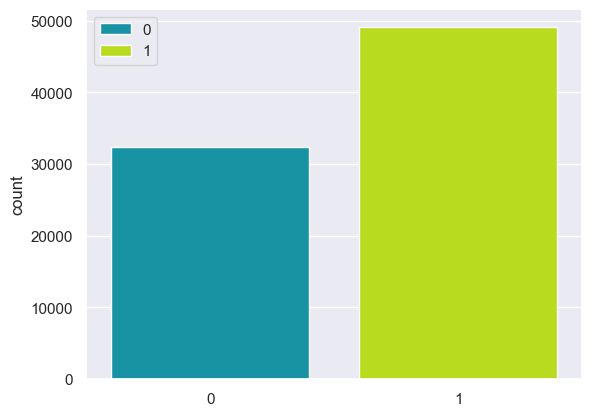

In [21]:
from collections import Counter
from matplotlib import pyplot as plt
import seaborn as sns

# Illustrate the imbalance between classification targets 
print(sorted(Counter(y_train).items()))
sns.set_style('white')
sns.set(font_scale=1)
plt.figure()
sns.countplot(x=y_train, hue=y_train, palette='nipy_spectral')
plt.show()

[(0, 49165), (1, 49165)]


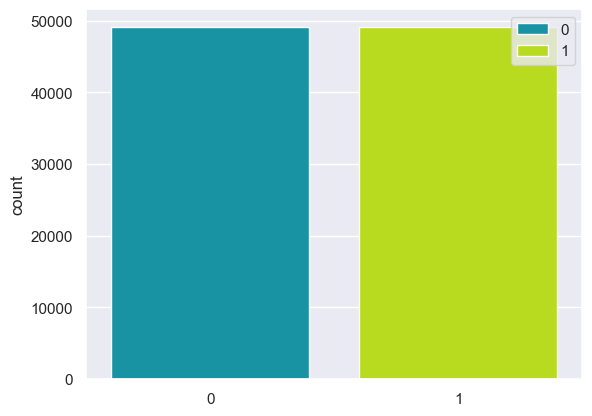

In [22]:
from imblearn.over_sampling import SMOTE

# Balance targets with RandomOverSampler
smote = SMOTE()
X_train, y_train = smote.fit_resample(X_train, y_train)

# Illustrate the balance between classification targets 
print(sorted(Counter(y_train).items()))
sns.set_style('white')
sns.set(font_scale=1)
plt.figure()
sns.countplot(x=y_train, hue=y_train,palette='nipy_spectral')
plt.show()

[<a href="#content">Back to top</a>]

## Machine Learning <a name="5"></a>

In [23]:
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, roc_auc_score
import matplotlib.pyplot as plt

# Instantiate the estimator 
model = XGBClassifier(random_state=42)

# Train  
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluation
acc = round(accuracy_score(y_test, y_pred),3)
print('Accuracy: ', acc)
pre = round(precision_score(y_test, y_pred),3)
print('Precision: ', pre) 
rec = round(recall_score(y_test, y_pred),3)
print('Recall: ',rec) 
f1 = round(f1_score(y_test, y_pred),3)
print('F1: ', f1) 
roc = round(roc_auc_score(y_test, y_pred),3) 
print('ROC: ', roc)

Accuracy:  0.882
Precision:  0.917
Recall:  0.884
F1:  0.9
ROC:  0.881


[<a href="#content">Back to top</a>]

## Scrutinizing for overfitting  <a name="6"></a>

In [24]:
# Evaluate random forest classifier performance on train and test sets with different tree depths
train_scores, test_scores = list(), list()
# define the tree depths to evaluate
values = [i for i in range(1, 31)]
# evaluate a decision tree for each depth
for i in values:
 # configure the model
 model_ = XGBClassifier(max_depth=i)
 # fit model_ on the training dataset
 model_.fit(X_train, y_train)
 # evaluate on the train dataset
 train_yhat = model_.predict(X_train)
 train_acc = accuracy_score(y_train, train_yhat)
 train_scores.append(train_acc)
 # evaluate on the test dataset
 test_yhat = model_.predict(X_test)
 test_acc = accuracy_score(y_test, test_yhat)
 test_scores.append(test_acc)
 # summarize progress
 print('>%d, train: %.3f, test: %.3f' % (i, train_acc, test_acc))

>1, train: 0.849, test: 0.833
>2, train: 0.871, test: 0.848
>3, train: 0.885, test: 0.858
>4, train: 0.897, test: 0.867
>5, train: 0.910, test: 0.875
>6, train: 0.924, test: 0.882
>7, train: 0.937, test: 0.888
>8, train: 0.951, test: 0.891
>9, train: 0.963, test: 0.894
>10, train: 0.973, test: 0.895
>11, train: 0.983, test: 0.896
>12, train: 0.990, test: 0.897
>13, train: 0.993, test: 0.898
>14, train: 0.997, test: 0.900
>15, train: 0.998, test: 0.902
>16, train: 0.999, test: 0.902
>17, train: 0.999, test: 0.901
>18, train: 1.000, test: 0.900
>19, train: 1.000, test: 0.900
>20, train: 1.000, test: 0.900
>21, train: 1.000, test: 0.901
>22, train: 1.000, test: 0.900
>23, train: 1.000, test: 0.900
>24, train: 1.000, test: 0.901
>25, train: 1.000, test: 0.899
>26, train: 1.000, test: 0.901
>27, train: 1.000, test: 0.901
>28, train: 1.000, test: 0.902
>29, train: 1.000, test: 0.900
>30, train: 1.000, test: 0.900


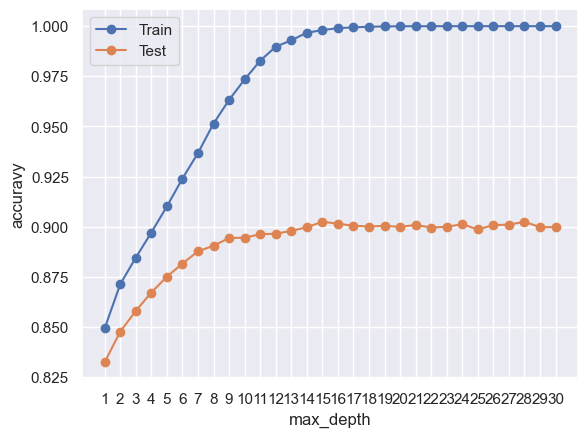

In [25]:
import math
import matplotlib.pyplot as plt

# Set integers for x axis
new_x_ticks = range(math.floor(min(values)), math.ceil(max(values))+1)
plt.xticks(new_x_ticks)
# Plot of train and test scores vs tree depth
plt.plot(values, train_scores, '-o', label='Train')
plt.plot(values, test_scores, '-o', label='Test')
plt.legend()
plt.xlabel("max_depth")
plt.ylabel("accuravy")
plt.show()

In [29]:
# ML model with max_depth=23
# Instantiate the estimator 
model = XGBClassifier(max_depth=7, random_state=42)

# Train  
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluation
acc = round(accuracy_score(y_test, y_pred),3)
print('Accuracy: ', acc)
pre = round(precision_score(y_test, y_pred),3)
print('Precision: ', pre) 
rec = round(recall_score(y_test, y_pred),3)
print('Recall: ',rec) 
f1 = round(f1_score(y_test, y_pred),3)
print('F1: ', f1) 
roc = round(roc_auc_score(y_test, y_pred),3) 
print('ROC: ', roc)

Accuracy:  0.888
Precision:  0.919
Recall:  0.892
F1:  0.906
ROC:  0.887


[<a href="#content">Back to top</a>]

## Five-fold cross-validation <a name="7"></a>

In [26]:
# Five-fold cross-validation
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix 
from imblearn.over_sampling import SMOTE
# from imblearn.pipeline import Pipeline # Important for combining steps


# Define the Model
model = XGBClassifier(max_depth=7, random_state=42)

# Number of folds
n_splits = 5

# Stratified K-Fold ensures balanced class distribution in each fold
# This ensures that each training and test fold has a similar percentage of class 1.
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Lists to store metrics from each fold
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []
roc_auc_scores = []

# --- 3. Cross-Validation Loop with Manual SMOTE Resampling ---
print(f"Performing {n_splits}-Fold Stratified Cross-Validation with Manual SMOTE...\n")

# Initialize the SMOTE object once
smote_sampler = SMOTE(random_state=42)

for fold, (train_index, test_index) in enumerate(skf.split(X_cv, y_cv)):
    print(f"--- Fold {fold + 1}/{n_splits} ---")

    # Split data for the current fold
    X_train_cv, X_test_cv = X_cv[train_index], X_cv[test_index]
    y_train_cv, y_test_cv = y_cv[train_index], y_cv[test_index]

    # Report class distributions before resampling
    print(f"  Training set class distribution (Original): {np.bincount(y_train_cv)}")
    print(f"  Test set class distribution: {np.bincount(y_test_cv)}")

    # Apply SMOTE oversampling on the training split only
    # This is the step that replaces the imblearn pipeline logic.
    X_train_resampled, y_train_resampled = smote_sampler.fit_resample(X_train_cv, y_train_cv)
    print(f"  Training set (after SMOTE) class distribution: {np.bincount(y_train_resampled)}")

    # Train the model on the resampled training data
    model.fit(X_train_resampled, y_train_resampled)

    # Make predictions on the *original, untouched* test data
    y_pred_cv = model.predict(X_test_cv)
    # Get probabilities for ROC AUC calculation
    y_prob_cv = model.predict_proba(X_test_cv)[:, 1]

    # Evaluate performance for the current fold
    accuracy = accuracy_score(y_test_cv, y_pred_cv)
    precision = precision_score(y_test_cv, y_pred_cv, zero_division=0)
    recall = recall_score(y_test_cv, y_pred_cv, zero_division=0)
    f1 = f1_score(y_test_cv, y_pred_cv, zero_division=0)
    roc_auc = roc_auc_score(y_test_cv, y_prob_cv)

    # Store scores
    accuracy_scores.append(accuracy)
    precision_scores.append(precision)
    recall_scores.append(recall)
    f1_scores.append(f1)
    roc_auc_scores.append(roc_auc)

    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall (Sensitivity): {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    print(f"  ROC AUC: {roc_auc:.4f}")
    print(f"  Confusion Matrix:\n{confusion_matrix(y_test_cv, y_pred_cv)}\n")
    print("-" * 30)


# --- 4. Aggregate and Report Final Metrics ---
print("\n--- Cross-Validation Results Summary ---")

# Convert lists to NumPy arrays for easier statistical manipulation
accuracy_scores = np.array(accuracy_scores)
precision_scores = np.array(precision_scores)
recall_scores = np.array(recall_scores)
f1_scores = np.array(f1_scores)
roc_auc_scores = np.array(roc_auc_scores)

print(f"Average Accuracy: {np.mean(accuracy_scores):.4f} +/- {np.std(accuracy_scores):.4f}")
print(f"Average Precision: {np.mean(precision_scores):.4f} +/- {np.std(precision_scores):.4f}")
print(f"Average Recall: {np.mean(recall_scores):.4f} +/- {np.std(recall_scores):.4f}")
print(f"Average F1-Score: {np.mean(f1_scores):.4f} +/- {np.std(f1_scores):.4f}")
print(f"Average ROC AUC: {np.mean(roc_auc_scores):.4f} +/- {np.std(roc_auc_scores):.4f}")
print("\n--- Summary ---")
print("The standard deviation (+/-) indicates the stability of the model performance across the different folds.")

Performing 5-Fold Stratified Cross-Validation with Manual SMOTE...

--- Fold 1/5 ---
  Training set class distribution (Original): [25858 39332]
  Test set class distribution: [6465 9833]
  Training set (after SMOTE) class distribution: [39332 39332]
  Accuracy: 0.8806
  Precision: 0.9138
  Recall (Sensitivity): 0.8857
  F1-Score: 0.8995
  ROC AUC: 0.9515
  Confusion Matrix:
[[5643  822]
 [1124 8709]]

------------------------------
--- Fold 2/5 ---
  Training set class distribution (Original): [25858 39332]
  Test set class distribution: [6465 9833]
  Training set (after SMOTE) class distribution: [39332 39332]
  Accuracy: 0.8842
  Precision: 0.9163
  Recall (Sensitivity): 0.8893
  F1-Score: 0.9026
  ROC AUC: 0.9530
  Confusion Matrix:
[[5666  799]
 [1089 8744]]

------------------------------
--- Fold 3/5 ---
  Training set class distribution (Original): [25858 39332]
  Test set class distribution: [6465 9833]
  Training set (after SMOTE) class distribution: [39332 39332]
  Accuracy:

[<a href="#content">Back to top</a>]

## Hyperparameter tuning with Optuna <a name="8"></a>

In [27]:
# Hyperparameter tuning with optuna
import optuna
from sklearn.model_selection import cross_val_score

def objective(trial):
    """
    Objective function for Optuna hyperparameter optimization.

    Args:
        trial: An Optuna trial object.

    Returns:
        The negative accuracy score (to be minimized).
    """
    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 1e-1, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 1e-3, 1),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10)
    }

    model = XGBClassifier(**params)
    accuracy = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy').mean()
    return -accuracy  # Optuna minimizes the objective function

# Create a study object
study = optuna.create_study(direction='minimize') 

# Run the optimization
study.optimize(objective, n_trials=5)  # Adjust n_trials as needed

# Get the best hyperparameters
best_params = study.best_params

# Train the model with the best hyperparameters
best_model = XGBClassifier(**best_params)
best_model.fit(X_train, y_train)

# Evaluate the best model on the test set
y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred) 
print(f"Best Accuracy: {accuracy}")
print(f"Best Hyperparameters: {best_params}")

[I 2025-10-26 15:54:06,882] A new study created in memory with name: no-name-99f3e24f-4e35-47a5-9c8f-bbc38d294616
[I 2025-10-26 15:55:18,340] Trial 0 finished with value: -0.8316790399674565 and parameters: {'max_depth': 3, 'learning_rate': 0.004771629935753997, 'n_estimators': 193, 'subsample': 0.6802247396201487, 'colsample_bytree': 0.6608008812585484, 'gamma': 0.2501903499532562, 'reg_lambda': 0.27236068485618586, 'min_child_weight': 6}. Best is trial 0 with value: -0.8316790399674565.
[I 2025-10-26 15:57:09,277] Trial 1 finished with value: -0.8575409335909694 and parameters: {'max_depth': 4, 'learning_rate': 0.021312487500683343, 'n_estimators': 294, 'subsample': 0.7777605308468715, 'colsample_bytree': 0.7717914583296452, 'gamma': 0.004478727814858254, 'reg_lambda': 3.7209027347995796, 'min_child_weight': 9}. Best is trial 1 with value: -0.8575409335909694.
[I 2025-10-26 15:58:49,428] Trial 2 finished with value: -0.8479406081562088 and parameters: {'max_depth': 5, 'learning_rate'

Best Accuracy: 0.8705085411348911
Best Hyperparameters: {'max_depth': 10, 'learning_rate': 0.025518509853990345, 'n_estimators': 170, 'subsample': 0.6930477439063405, 'colsample_bytree': 0.9147354295283276, 'gamma': 0.9597157319015951, 'reg_lambda': 0.02114340522875077, 'min_child_weight': 3}


[<a href="#content">Back to top</a>]

##  Confusion matrix <a name="9"></a>

[10966, 7119, 962, 1325]

--- Classification Metrics ---
True Positives (TP): 10966
True Negatives (TN): 7119
False Positives (FP): 962
False Negatives (FN): 1325
----------------------------



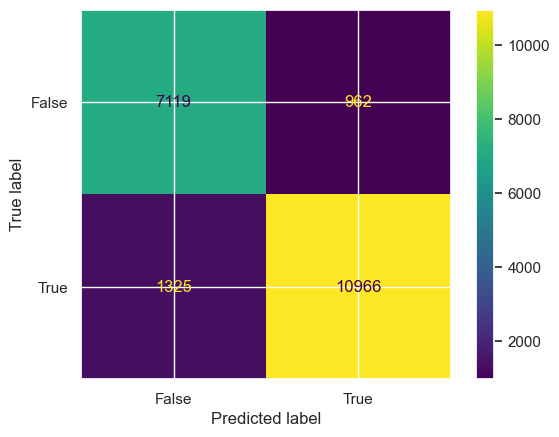

In [31]:
from sklearn import metrics

# Random forest classifier prediction
predicted = XGBClassifier(max_depth=7).fit(X_train,y_train).predict(X_test)

# # Calculate the confusion matrix
confusion_matrix = metrics.confusion_matrix(y_test, predicted)

# Extract TP, TN, FP, FN 
# Use .ravel() to flatten the 2x2 matrix into a 1x4 array: [TN, FP, FN, TP]
TN, FP, FN, TP = confusion_matrix.ravel()
conf_matrix_list = [TP, TN, FP, FN]

# Print the list with metrics
print(conf_matrix_list)

# Print the metrics
print("\n--- Classification Metrics ---")
print(f"True Positives (TP): {TP}")
print(f"True Negatives (TN): {TN}")
print(f"False Positives (FP): {FP}")
print(f"False Negatives (FN): {FN}")
print("----------------------------\n")

# Display confusion matrix
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [False, True])
cm_display.plot()
plt.show()

[<a href="#content">Back to top</a>]

## Matthews correlation coeficient (MCC)<a name="10"></a>

In [32]:
# import math

def matthews_corr_coeff(TP: int, TN: int, FP: int, FN: int) -> float:
    """
    Calculates the Matthews Correlation Coefficient (MCC).

    MCC is a metric used to evaluate the quality of binary classifications.
    It takes into account true positives, true negatives, false positives, 
    and false negatives, making it a reliable measure even for imbalanced classes.

    The formula is:
    MCC = (TP * TN - FP * FN) / sqrt((TP + FP)(TP + FN)(TN + FP)(TN + FN))

    Args:
        TP (int): True Positives (correctly predicted positive cases).
        TN (int): True Negatives (correctly predicted negative cases).
        FP (int): False Positives (incorrectly predicted positive cases).
        FN (int): False Negatives (incorrectly predicted negative cases).

    Returns:
        float: The Matthews Correlation Coefficient, ranging from -1 (worst) 
               to +1 (best). Returns 0.0 if the denominator is zero.
    """
    
    # Calculate the numerator: (TP * TN) - (FP * FN)
    numerator = (TP * TN) - (FP * FN)
    
    # Calculate the components of the denominator
    # Note: These components are the marginal sums (sums of rows/columns in the confusion matrix)
    term_1 = TP + FP
    term_2 = TP + FN
    term_3 = TN + FP
    term_4 = TN + FN
    
    # Calculate the denominator: sqrt((TP + FP)(TP + FN)(TN + FP)(TN + FN))
    denominator = math.sqrt(term_1 * term_2 * term_3 * term_4)
    
    # Handle the case where the denominator is zero (which means one of the marginal
    # sums is zero, indicating an ill-defined problem or a trivial prediction). 
    # In this case, MCC is conventionally set to 0.
    if denominator == 0:
        print("Warning: Denominator is zero. Returning MCC = 0.0")
        return 0.0
    
    # Calculate the final MCC value
    mcc = numerator / denominator
    return mcc


# tp1, tn1, fp1, fn1 = [10168, 7042, 1039, 2123]
tp1, tn1, fp1, fn1 = conf_matrix_list
mcc1 = matthews_corr_coeff(tp1, tn1, fp1, fn1)
print(f"--- Model ---")
print(f"TP={tp1}, TN={tn1}, FP={fp1}, FN={fn1}")
print(f"MCC: {mcc1:.4f}\n")

--- Model ---
TP=10966, TN=7119, FP=962, FN=1325
MCC: 0.7678



[<a href="#content">Back to top</a>]